<a href="https://colab.research.google.com/github/guidoparra/Proyecto-Integrador-Data-Science-I-/blob/main/ProyectoParteIII_ParraGuido.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyecto Final - Data Science I

## Predicción de Producción de Gas en Pozos

En este proyecto se aplica un flujo básico de trabajo de Machine Learning utilizando un dataset de producción de pozos de gas y petróleo en Argentina año 2025.

El objetivo del trabajo es construir un modelo predictivo que permita estimar la producción de gas de un pozo a partir de variables operativas y geológicas disponibles en el dataset.

Para ello se utilizarán diferentes etapas del pipeline de ciencia de datos:

- Exploración y preprocesamiento de datos
- Selección de variables (feature selection)
- Entrenamiento de un modelo de Machine Learning
- Evaluación del modelo mediante métricas de regresión

Las herramientas utilizadas serán Python, junto con las librerías NumPy, Pandas y Scikit-Learn.

## Importación de librerías

Se importan las librerías necesarias para el análisis, preprocesamiento y modelado de los datos.

In [31]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_regression

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

## Carga del dataset

El dataset contiene información histórica sobre la producción de pozos de gas y petróleo en Argentina.

Cada registro representa la producción mensual de un pozo, junto con diversas variables descriptivas como:

- ubicación geográfica
- características del pozo
- producción de gas, agua y petróleo

A continuación se carga el dataset para comenzar con el análisis exploratorio.

In [32]:
df = pd.read_csv('/content/produccion_de_pozos_de_gas_y_petroleo-2025.csv')

df.head()

/tmp/ipykernel_389/189961658.py:1: DtypeWarning: Columns (36) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/produccion_de_pozos_de_gas_y_petroleo-2025.csv')


,idempresa,anio,mes,idpozo,prod_pet,prod_gas,prod_agua,iny_agua,iny_gas,iny_co2,...,areayacimiento,cuenca,provincia,tipo_de_recurso,proyecto,clasificacion,subclasificacion,sub_tipo_recurso,fecha_data,id
0,Z001,2025,1,32189,0.0,0.0,0.0,0.0,0.0,0.0,...,"BLANCO DE LOS OLIVOS-BLOQUE ""A""",NEUQUINA,Rio Negro,CONVENCIONAL,Sin Proyecto,EXPLORACION,EXPLORACION,NaN,2025-01-31,32189202501
1,Z001,2025,1,32187,0.0,0.0,0.0,0.0,0.0,0.0,...,"BLANCO DE LOS OLIVOS-BLOQUE ""A""",NEUQUINA,Rio Negro,CONVENCIONAL,Sin Proyecto,EXPLORACION,EXPLORACION,NaN,2025-01-31,32187202501
2,Z001,2025,1,144117,0.0,0.0,0.0,0.0,0.0,0.0,...,PUESTO SURVELIN,NEUQUINA,Rio Negro,CONVENCIONAL,Sin Proyecto,EXPLORACION,EXPLORACION,NaN,2025-01-31,144117202501
3,Z001,2025,1,32186,0.0,0.0,0.0,0.0,0.0,0.0,...,PUESTO SURVELIN,NEUQUINA,Rio Negro,CONVENCIONAL,Sin Proyecto,EXPLORACION,EXPLORACION,NaN,2025-01-31,32186202501
4,Z001,2025,1,145619,0.0,0.0,0.0,0.0,0.0,0.0,...,FLOR DE ROCA,NEUQUINA,Rio Negro,CONVENCIONAL,Sin Proyecto,EXPLORACION,EXPLORACION,NaN,2025-01-31,145619202501


## Exploración inicial de los datos

Antes de aplicar técnicas de Machine Learning es importante comprender la estructura del dataset:

- cantidad de registros
- tipos de variables
- presencia de valores faltantes

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 989386 entries, 0 to 989385
Data columns (total 39 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   idempresa               989386 non-null  object 
 1   anio                    989386 non-null  int64  
 2   mes                     989386 non-null  int64  
 3   idpozo                  989386 non-null  int64  
 4   prod_pet                989386 non-null  float64
 5   prod_gas                989386 non-null  float64
 6   prod_agua               989386 non-null  float64
 7   iny_agua                989386 non-null  float64
 8   iny_gas                 989386 non-null  float64
 9   iny_co2                 989386 non-null  float64
 10  iny_otro                989386 non-null  float64
 11  tef                     989386 non-null  float64
 12  vida_util               72145 non-null   float64
 13  tipoextraccion          989353 non-null  object 
 14  tipoestado          

In [34]:
df.describe()

,anio,mes,idpozo,prod_pet,prod_gas,prod_agua,iny_agua,iny_gas,iny_co2,iny_otro,tef,vida_util,idusuario,profundidad,id
count,989386.0,989386.000000,989386.000000,989386.000000,989386.000000,989386.000000,989386.000000,9.893860e+05,989386.0,989386.000000,989386.000000,72145.0,989386.000000,989386.000000,9.893860e+05
mean,2025.0,6.491711,103253.570841,46.936710,52.100888,334.087504,336.819495,3.516815e+01,0.0,1.446912,10.086246,0.0,390.759918,1706.760016,1.032538e+11
std,0.0,3.446083,42873.258493,311.625698,881.495789,1147.998790,1997.173882,1.189676e+04,0.0,216.834258,13.937944,0.0,59.872534,1739.500335,4.287326e+10
min,2025.0,1.000000,212.000000,-0.080000,-12.140000,-12.110000,0.000000,0.000000e+00,0.0,0.000000,-23.000000,0.0,3.000000,0.000000,2.122025e+08
25%,2025.0,3.000000,71492.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.0,0.000000,0.000000,0.0,334.000000,1051.000000,7.149220e+10
50%,2025.0,6.000000,110908.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.0,0.000000,0.000000,0.0,367.000000,1600.000000,1.109082e+11
75%,2025.0,9.000000,133765.750000,6.680000,0.000000,11.000000,0.000000,0.000000e+00,0.0,0.000000,29.190000,0.0,462.000000,2350.000000,1.337660e+11
max,2025.0,12.000000,167046.000000,26593.261000,133520.000000,37771.490000,218837.800000,9.267366e+06,0.0,47396.750000,60.000000,0.0,491.000000,378939.000000,1.670462e+11


## Selección de variables

El dataset original contiene una gran cantidad de columnas, algunas de las cuales no aportan información relevante para el modelo o corresponden a identificadores.

Por esta razón se seleccionan únicamente variables con potencial explicativo sobre la producción de gas.

La variable objetivo será:

**prod_gas → producción de gas**

Las demás variables se utilizarán como predictores.

In [35]:
columns = [
    'anio',
    'mes',
    'prod_gas',
    'prod_agua',
    'tef',
    'vida_util',
    'profundidad',
    'provincia',
    'cuenca',
    'tipo_de_recurso',
    'prod_pet'
]

df = df[columns]

## Preprocesamiento de datos

Antes de entrenar un modelo es necesario preparar los datos:

1. Eliminación de valores faltantes
2. Conversión de variables categóricas a formato numérico

Los algoritmos de Machine Learning requieren variables numéricas para poder operar correctamente.

In [36]:
df = df.dropna()

In [37]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['provincia'] = le.fit_transform(df['provincia'])
df['cuenca'] = le.fit_transform(df['cuenca'])
df['tipo_de_recurso'] = le.fit_transform(df['tipo_de_recurso'])

## Definición de variables predictoras y variable objetivo

Se separa el dataset en:

X → variables predictoras  
y → variable objetivo (producción de gas)

In [38]:
X = df.drop("prod_gas", axis=1)
y = df["prod_gas"]

## Selección de variables (Feature Selection)

Para reducir la dimensionalidad del dataset y seleccionar las variables más relevantes se utiliza el método **SelectKBest** basado en la prueba estadística **f_regression**.

Este método evalúa la relación entre cada variable predictora y la variable objetivo, seleccionando aquellas con mayor poder explicativo.

In [39]:
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_regression

selector = SelectKBest(score_func=f_regression, k=6)

X_new = selector.fit_transform(X, y)

## División en conjunto de entrenamiento y prueba

Para evaluar correctamente el desempeño del modelo se divide el dataset en:

- **80% entrenamiento**
- **20% prueba**

Esto permite medir la capacidad de generalización del modelo sobre datos no vistos.

In [40]:
X_train, X_test, y_train, y_test = train_test_split(
    X_new, y, test_size=0.2, random_state=42
)

## Entrenamiento del modelo

Se utiliza el algoritmo **Random Forest Regressor**, un método basado en ensamble de árboles de decisión.

Este algoritmo es adecuado para datasets grandes y puede capturar relaciones no lineales entre variables.

In [41]:
model = RandomForestRegressor(n_estimators=100, random_state=42)

model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [42]:
y_pred = model.predict(X_test)

## Evaluación del modelo

Para evaluar el desempeño del modelo se utilizan dos métricas comunes en problemas de regresión:

- **RMSE (Root Mean Squared Error)**: mide el error promedio de las predicciones
- **R² (coeficiente de determinación)**: indica qué proporción de la variabilidad de los datos es explicada por el modelo

In [43]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R2:", r2)

RMSE: 0.598949960593857
R2: 0.5062464142395078


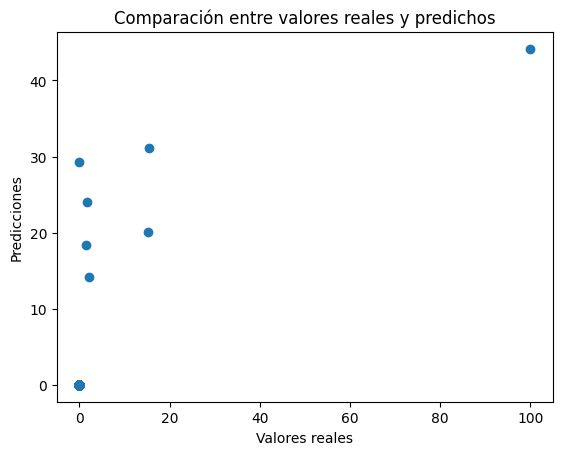

In [44]:
plt.scatter(y_test, y_pred)
plt.xlabel("Valores reales")
plt.ylabel("Predicciones")
plt.title("Comparación entre valores reales y predichos")
plt.show()

# **Conclusiones**

En este trabajo se desarrolló un modelo de Machine Learning para estimar la producción de gas de pozos a partir de diferentes variables operativas y geológicas del dataset.

Durante el proceso se aplicaron distintas etapas del flujo de trabajo de ciencia de datos:

- preprocesamiento y limpieza de datos

- selección de variables mediante técnicas de feature selection

- entrenamiento de modelos de regresión

- evaluación del desempeño mediante métricas cuantitativas

Se utilizó el método SelectKBest con la función estadística f_regression para reducir la dimensionalidad del dataset y seleccionar las variables con mayor relación estadística con la variable objetivo.

Posteriormente se entrenó un modelo Random Forest Regressor, el cual permitió capturar patrones presentes en los datos y generar predicciones sobre la producción de gas.

Los resultados obtenidos muestran que el modelo logra aproximar la relación entre las variables del dataset, aunque con cierta dispersión en las predicciones, lo cual es esperable en problemas reales donde intervienen múltiples factores operativos y geológicos.